# Alg 1

In [54]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import json
import cv2
import cupy as cp
import math
from numpy.lib.stride_tricks import sliding_window_view,as_strided
from datetime import datetime

In [ ]:
!pip install opencv-contrib-python

In [2]:
!pip install cupy-cuda12x

   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB 393.8 kB/s eta 0:02:57
   ---------------------------------------- 0.1/69.5 MB 901.1 kB/s eta 0:01:17
   ---------------------------------------- 0.3/69.5 MB 1.7 MB/s eta 0:00:41
   ---------------------------------------- 0.7/69.5 MB 2.8 MB/s eta 0:00:25
    --------------------------------------- 1.2/69.5 MB 4.3 MB/s eta 0:00:16
    --------------------------------------- 1.7/69.5 MB 5.1 MB/s eta 0:00:14
    --------------------------------------- 1.7/69.5 MB 5.1 MB/s eta 0:00:14
   - -------------------------------------- 2.0/69.5 MB 4.7 MB/s eta 0:00:15
   - -------------------------------------- 2.2/69.5 MB 4.7 MB/s eta 0:00:15
   - -------------------------------------- 2.6/69.5 MB 5.1 MB/s eta 0:00:14
   - -------------------------------------- 3.1/69.5 MB 5.4 MB/s eta 0:00:13
   -- ---

In [2]:
print(cp.cuda.runtime.getDeviceCount())

1


In [267]:
with open('TILDA_Fabric.v2-tilda-v2.coco/train/_annotations.coco.json') as f:
    coco_data = json.load(f)

# Convert images and annotations into DataFrames
images_df = pd.DataFrame(coco_data['images'])
annotations_df = pd.DataFrame(coco_data['annotations'])
categories_df = pd.DataFrame(coco_data['categories'])


In [8]:
images_df

,id,license,file_name,height,width,date_captured
0,0,1,c1r1e3n25_jpg.rf.ecaca7ca7c378f4da214df04a409d...,416,416,2022-06-27T08:05:00+00:00
1,1,1,c1r1e2n2_jpg.rf.ecac8f76c430d0814741bda4650a9a...,416,416,2022-06-27T08:05:00+00:00
2,2,1,c1r3e2n19_jpg.rf.eda23f406c233ea71a5eb96bf49e0...,416,416,2022-06-27T08:05:00+00:00
3,3,1,c1r3e1n32_jpg.rf.ed0ba64a67f1500a4c1fa9747f882...,416,416,2022-06-27T08:05:00+00:00
4,4,1,c1r3e4n23_jpg.rf.ee6810040f7bc881ed020bb2e0d16...,416,416,2022-06-27T08:05:00+00:00
...,...,...,...,...,...,...
771,771,1,c1r1e4n14_jpg.rf.ead581ed844b8469a6657fe5a4b72...,416,416,2022-06-27T08:05:00+00:00
772,772,1,c1r3e1n30_jpg.rf.eb50c59625990e213a0299bd76d69...,416,416,2022-06-27T08:05:00+00:00
773,773,1,c1r1e4n23_jpg.rf.ec227119011a27b0d6cb45ffaffe3...,416,416,2022-06-27T08:05:00+00:00
774,774,1,c1r1e2n29_jpg.rf.ec5415d6debe2741368e0f7294747...,416,416,2022-06-27T08:05:00+00:00


In [268]:
annotations_df

,id,image_id,category_id,bbox,area,segmentation,iscrowd
0,0,0,4,"[272, 300, 78, 56]",4368,[],0
1,1,1,3,"[35, 13, 60, 95]",5700,[],0
2,2,2,3,"[73, 148, 248, 182]",45136,[],0
3,3,3,1,"[161, 0, 153, 204]",31212,[],0
4,4,4,2,"[183, 1, 232, 265]",61480,[],0
...,...,...,...,...,...,...,...
921,921,771,2,"[0, 238, 415, 75]",31125,[],0
922,922,772,1,"[151, 83, 126, 39]",4914,[],0
923,923,773,2,"[60, 24, 355, 391]",138805,[],0
924,924,774,3,"[176, 225, 104, 158]",16432,[],0


In [10]:
categories_df

,id,name,supercategory
0,0,Fabric,none
1,1,hole,Fabric
2,2,objects,Fabric
3,3,oil spot,Fabric
4,4,thread error,Fabric


## Map Category IDs to Names

In [269]:
category_map = {cat['id']: cat['name'] for cat in coco_data['categories']}
annotations_df['category_name'] = annotations_df['category_id'].map(category_map)

In [12]:
annotations_df

,id,image_id,category_id,bbox,area,segmentation,iscrowd,category_name
0,0,0,4,"[272, 300, 78, 56]",4368,[],0,thread error
1,1,1,3,"[35, 13, 60, 95]",5700,[],0,oil spot
2,2,2,3,"[73, 148, 248, 182]",45136,[],0,oil spot
3,3,3,1,"[161, 0, 153, 204]",31212,[],0,hole
4,4,4,2,"[183, 1, 232, 265]",61480,[],0,objects
...,...,...,...,...,...,...,...,...
921,921,771,2,"[0, 238, 415, 75]",31125,[],0,objects
922,922,772,1,"[151, 83, 126, 39]",4914,[],0,hole
923,923,773,2,"[60, 24, 355, 391]",138805,[],0,objects
924,924,774,3,"[176, 225, 104, 158]",16432,[],0,oil spot


In [270]:
def visualize_image_with_bboxes(image_path, annotations):
    image = cv2.imread(image_path)
    new_width = 200  # Desired width
    new_height = 200  # Desired height
    image = cv2.resize(image, (new_width, new_height))
    print(image.shape)
    # Loop through annotations and draw bounding boxes
    for idx, row in annotations.iterrows():
        bbox = row['bbox']  # [x, y, width, height]
        category_name = row['category_name']
        # start_point = (int(bbox[0]), int(bbox[1]))
        # end_point = (int((bbox[0] + bbox[2])), int((bbox[1] + bbox[3])))
        # Draw rectangle
        start_point = (int(bbox[0]/416*200), int(bbox[1]/416*200))
        end_point = (int((bbox[0] + bbox[2])/416*200), int((bbox[1] + bbox[3])/416*200))
        color = (0, 255, 0)  # Green color
        thickness = 1
        image = cv2.rectangle(image, start_point, end_point, color, thickness)

        # Put category name
        cv2.putText(image, category_name, (start_point[0], start_point[1] - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.3, color, thickness)
    
    plt.imshow(image)
    plt.title('Image with Bounding Boxes',fontweight="bold")
    plt.axis('off')
    plt.show()
    # Display the image
    # cv2.imshow("Image with Bounding Boxes", image)
    # cv2.waitKey(0)
    # cv2.destroyAllWindows()
def grabcut(image_path,annotations):
    image = cv2.imread(image_path)
    for idx, row in annotations.iterrows():
        bbox = row['bbox']  # [x, y, width, height]
        cropImage=image[int(bbox[1]):bbox[3]+int(bbox[1]),int(bbox[0]):int(bbox[0])+bbox[2]]
        print(bbox)
        # category_name = row['category_name']

        # # Draw rectangle
        # start_point = (int(bbox[0]), int(bbox[1]))
        # end_point = (int(bbox[0] + bbox[2]), int(bbox[1] + bbox[3]))
        # color = (0, 255, 0)  # Green color
        # thickness = 2
        # image = cv2.rectangle(image, start_point, end_point, color, thickness)

        # Put category name
        # cv2.putText(image, category_name, (start_point[0], start_point[1] - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, thickness)
    # mask = np.zeros(image.shape[:2], np.uint8)
    # backgroundModel = np.zeros((1, 65), np.float64)
    # foregroundModel = np.zeros((1, 65), np.float64)
    # rectangle =(int(bbox[0]),int(bbox[1]),int(bbox[2]),int(bbox[3]))
    # cv2.grabCut(image, mask, rectangle,  
    #         backgroundModel, foregroundModel,
    #         3, cv2.GC_INIT_WITH_RECT)
    # mask2 = np.where((mask == 2)|(mask == 0), 0, 1).astype('uint8')
    # image_segmented = image * mask2[:, :, np.newaxis]
    plt.subplot(1, 2, 1)
    plt.title('Original Image')
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    
    # Display the segmented image
    plt.subplot(1, 2, 2)
    plt.title('Segmented Image')
    plt.imshow(cv2.cvtColor(cropImage, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    
    plt.show()


TILDA_Fabric.v2-tilda-v2.coco/train/c1r1e3n25_jpg.rf.ecaca7ca7c378f4da214df04a409d57c.jpg
(200, 200, 3)


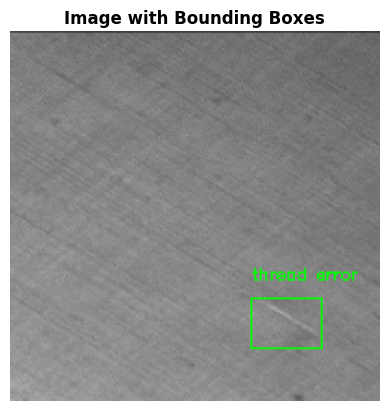

In [271]:
# Example usage
image_id = 0  # ID of the image you want to display
image_info = images_df[images_df['id'] == image_id].iloc[0]
image_path = f"TILDA_Fabric.v2-tilda-v2.coco/train/{image_info['file_name']}"
# Get annotations for this image
image_annotations = annotations_df[annotations_df['image_id'] == image_id]
print(image_path)
# Visualize
visualize_image_with_bboxes(image_path, image_annotations)
# grabcut(image_path, image_annotations)

In [14]:
image_path

'TILDA_Fabric.v2-tilda-v2.coco/train/c1r1e3n25_jpg.rf.ecaca7ca7c378f4da214df04a409d57c.jpg'

In [7]:
image = cv2.imread(image_path)
all_pixels = image.reshape(-1, 3).astype(np.float32)
image.shape,all_pixels.shape

((416, 416, 3), (173056, 3))

In [281]:
K = 64
C = 1
def create_patches(image, patch_size=7):
    # Create sliding windows of the given patch size
    patches = cp.lib.stride_tricks.sliding_window_view(image, (patch_size, patch_size, image.shape[2])).astype(cp.float32)
    return patches
# def create_patches(image, patch_size=7):
#     # Calculate the shape for the sliding windows
#     image_shape = image.shape
#     patch_shape = (image_shape[0] - patch_size + 1, image_shape[1] - patch_size + 1, patch_size, patch_size, image_shape[2])

#     # Calculate the strides for creating the sliding windows
#     strides = image.strides[:2] + image.strides[:2] + image.strides[2:]

#     # Create the sliding windows using as_strided
#     patches = cp.lib.stride_tricks.as_strided(image, shape=patch_shape, strides=strides)

#     # Reshape to match the desired output format
#     patches = patches.reshape(-1, 1, patch_size * patch_size, image_shape[2])

#     return patches
def color_distance_vectorized(src, r, c,patch_size):
    # Calculate color distances from the pixel at (r, c) to all other pixels in the image
    c1 = src[r, c].astype(cp.float32)
    # Calculate half the patch size
    half_patch = patch_size // 2

    # Extract the 7x7 patch centered at (r, c)
    start_row = max(0, r - half_patch)
    end_row = min(src.shape[0], r + half_patch + 1)
    start_col = max(0, c - half_patch)
    end_col = min(src.shape[1], c + half_patch + 1)

    patch = src[start_row:end_row, start_col:end_col].astype(cp.float32)
    patch=patch.reshape(-1,3)
    neighbor_patches=create_patches(src,patch_size)
    
    neighbor_patches=neighbor_patches.reshape(-1,neighbor_patches.shape[2],neighbor_patches.shape[3],neighbor_patches.shape[4],neighbor_patches.shape[5])
    neighbor_patches=neighbor_patches.reshape(neighbor_patches.shape[0],neighbor_patches.shape[1],neighbor_patches.shape[2]*neighbor_patches.shape[3],neighbor_patches.shape[4])
    
    # all_pixels = src.reshape(-1, 3).astype(cp.float32)
    dc = (neighbor_patches - patch) / 255.0
    color_distances = cp.linalg.norm(dc, axis=(1,2))
    color_distances = np.linalg.norm(color_distances,axis=1)
    return color_distances

def distance_vectorized(src, r, c, rows, cols,patch_size):
    # Calculate color distance using the vectorized function
    color_distances = color_distance_vectorized(src, r, c,patch_size)
    # Calculate spatial distances from the pixel (r, c) to all other pixels
    row_indices, col_indices = cp.indices((rows, cols))
    larger_dimen=rows if rows >cols else cols
    row_indices=row_indices[int(patch_size//2):-int(patch_size//2),int(patch_size//2):-int(patch_size//2)]
    col_indices=col_indices[int(patch_size//2):-int(patch_size//2),int(patch_size//2):-int(patch_size//2)]
    # print(len(row_indices))
    # print(f'why:{row_indices.flatten()[int(patch_size//2):-int(patch_size//2)]}')
    dRow = (row_indices.flatten() - r) / larger_dimen
    dCol = (col_indices.flatten() - c) / larger_dimen
    xy_distances = cp.sqrt(dRow**2 + dCol**2)
    # Combine color and spatial distances
    combined_distances = color_distances / (1 + C * xy_distances)
    return combined_distances

def salient(src, r, c, rows, cols,patch_size):
    # Get the vectorized distance array
    distances = distance_vectorized(src, r, c, rows, cols,patch_size)
    # Sort the distances and select the smallest K
    smallest_diffs = cp.partition(distances, K)[:K]
    sum_diff = cp.sum(smallest_diffs)

    # Calculate the saliency value
    return 1 - math.exp(-sum_diff / K)
def saliencyMatrix(src, u,patch_size):
    src = src.copy()
    ###Cupy
    ###
    rows, cols, _ = src.shape
    for row in range(rows):
        for col in range(cols):
            n, l, a, b = 0, 0.0, 0.0, 0.0  # Initialize l, a, b as floats to prevent overflow
            for r in range(max(row - u, 0), min(row + u + 1, rows)):
                for c in range(max(col - u, 0), min(col + u + 1, cols)):
                    n += 1
                    l += float(src[r, c][0])  # Cast to float to avoid overflow
                    a += float(src[r, c][1])
                    b += float(src[r, c][2])
            # Store the average back in the src matrix, converting to integers
            src[row, col] = (int(l / n), int(a / n), int(b / n))
    # tg = np.zeros((rows, cols), dtype=np.uint8)
    # mid = np.zeros((rows, cols), dtype=np.float64)
    src = cp.asarray(src)
    tg = cp.zeros((rows, cols), dtype=cp.uint8)
    mid = cp.zeros((rows, cols), dtype=cp.float32)
    _max = 0.0
    print(f'Generating at u={u}')
    for row in range(patch_size//2,rows-patch_size//2):
        print(f"{row}\n")
        for col in range(patch_size//2,cols-patch_size//2):
            value = salient(src, row, col, rows, cols,patch_size)
            mid[row, col] = value
            if value > _max:
                _max = value
    print("Done salient \n")
    # for row in range(rows):
    #     for col in range(cols):
    #         tg[row, col] = np.uint8((mid[row, col] / _max) * 255)
    # tg = cp.uint8((mid / _max) * 255)
    tg = (mid / _max) * 255  # Compute the normalized values
    tg = cp.clip(tg, 0, 255)  # Clip the values to the range [0, 255]
    tg = tg.astype(cp.uint8)  # Convert to uint8

    tg = tg.get()
    return tg

def exec(image_id,json_path,image_path,filename, u,patck_size=7):
    image = cv2.imread(image_path)
    old_height,old_width,_=image.shape
    new_width = 200  # Desired width
    new_height = 200  # Desired height
    image = cv2.resize(image, (new_width, new_height))
    # plt.imshow(image)
    # plt.title('Image with Bounding Boxes',fontweight="bold")
    # plt.axis('off')
    # plt.show()
    image_annotations = annotations_df[annotations_df['image_id'] == image_id]
    for idx, row in image_annotations.iterrows():
        # print(row['bbox']/2)
        bbox = row['bbox'][:] # [x, y, width, height]
        print(bbox[0]/2)
        bbox[0]=int(bbox[0]/old_height*new_height)
        bbox[1]=int(bbox[1]/old_height*new_height)
        bbox[2]=int(bbox[2]/old_height*new_height)
        bbox[3]=int(bbox[3]/old_height*new_height)# [x, y, width, height]
        add_annotation_to_json(row['id'],image_id,row['category_id'],bbox,bbox[2]*bbox[3],json_path)
    ########################
    #     cropImage=image[int(bbox[1]):bbox[3]+int(bbox[1]),int(bbox[0]):int(bbox[0])+bbox[2]]
    # # Draw rectangle
    # cropImage=image[int(bbox[1]):bbox[3]+int(bbox[1]),int(bbox[0]):int(bbox[0])+bbox[2]]
    # plt.imshow(cropImage)
    # plt.title('Image with Bounding Boxes',fontweight="bold")
    # plt.axis('off')
    # plt.show()
    #######################
    source = cv2.cvtColor(image, cv2.COLOR_BGR2Lab)
    rows, cols, _ = source.shape
    print(f'rows: {rows}, cols: {cols}')
    
    tg4 = saliencyMatrix(source, 0,patck_size)
    cv2.imwrite(f"SaliencyTILDA/train/7_size/{filename}.7.jpg" , tg4)
    tg2 = saliencyMatrix(source, u ,patck_size-u)
    cv2.imwrite(f"SaliencyTILDA/train/5_size/{filename}.5.jpg", tg2)
    tg0 = saliencyMatrix(source, 2*u,patck_size-2*u)
    cv2.imwrite(f"SaliencyTILDA/train/3_size/{filename}.3.jpg", tg0)
    tg = np.zeros((rows, cols), dtype=np.uint8)
    
    mainPart = []
    _max = 0
    for row in range(rows):
        for col in range(cols):
            avg = np.uint8((int(tg4[row, col]) + int(tg2[row, col]) + int(tg0[row, col]))/3 )
            tg[row, col] = avg
            if avg > _max:
                _max = avg
    print(f'tg max: {_max}')
    for row in range(rows):
        for col in range(cols):
            tg[row, col] = np.uint8((tg[row, col] * 255.0) / _max)
            if tg[row, col] > 204:
                mainPart.append(((row, col), tg[row, col]))
    cv2.imwrite(f"SaliencyTILDA/train/average/{filename}.average.jpg", tg)

    S = tg.copy()
    print(f'len: {len(mainPart)}')
    print('Optimizing')
    if mainPart:
        print("Calculating...")
        for row in range(rows):
            for col in range(cols):
                value = S[row, col]
                if value > 204:
                    continue
                dis = 1.0
                for p in mainPart:
                    dRow = (p[0][0] - row) / rows
                    dCol = (p[0][1] - col) / cols
                    _dis = math.sqrt(dRow * dRow + dCol * dCol)
                    if _dis < dis:
                        dis = _dis
                S[row, col] = np.uint8(value * (1.0 - dis))
    # cv2.imwrite(filename + ".fin.png", S)
    cv2.imwrite(f"SaliencyTILDA/train/final/{filename}.final.jpg", S)
    add_image_to_json(image_id,json_path,f"final/{filename}.final.jpg",new_height,new_width)

def add_image_to_json(new_image_id,json_path, file_name, height, width):
    # Load existing COCO JSON file
    with open(json_path, 'r') as file:
        coco_data = json.load(file)
    
    def make_serializable(obj):
        if isinstance(obj, pd.Series):
            return obj.to_dict()  # Convert Series to a dictionary
        elif isinstance(obj, pd.DataFrame):
            return obj.to_dict(orient='records')  # Convert DataFrame to a list of dictionaries
        elif isinstance(obj, np.ndarray):
            return obj.tolist()  # Convert NumPy arrays to lists
        else:
            return obj
    coco_data = make_serializable(coco_data)

    # Create new image entry
    # print(new_image_id)
    new_image_entry = {
        "id": int(new_image_id),
        "license": 1,  # Assuming the same license ID
        "file_name": file_name,
        "height": height,
        "width": width,
        "date_captured": datetime.now().strftime("%Y-%m-%dT%H:%M:%S+00:00")
    }
    
    # Append the new image entry
    coco_data["images"].append(new_image_entry)

    # Save the updated JSON file
    with open(json_path, 'w') as file:
        json.dump(coco_data, file, indent=4)

def add_annotation_to_json(annotation_id,new_image_id,category_id,bbox,area,json_path):
    # Load existing COCO JSON file
    with open(json_path, 'r') as file:
        coco_data = json.load(file)
    
    def make_serializable(obj):
        if isinstance(obj, pd.Series):
            return obj.to_dict()  # Convert Series to a dictionary
        elif isinstance(obj, pd.DataFrame):
            return obj.to_dict(orient='records')  # Convert DataFrame to a list of dictionaries
        elif isinstance(obj, np.ndarray):
            return obj.tolist()  # Convert NumPy arrays to lists
        else:
            return obj
    coco_data = make_serializable(coco_data)

    # Create new image entry
    # print(new_image_id)
    new_annotation_entry = {
        "id": int(annotation_id),
        "image_id": int(new_image_id),
        "category_id": int(category_id),
        "bbox": bbox,
        "area": int(area),
        "segmentation": [],
        "iscrowd": 0
    }
    
    # Append the new image entry
    coco_data["annotations"].append(new_annotation_entry)

    # Save the updated JSON file
    with open(json_path, 'w') as file:
        json.dump(coco_data, file, indent=4)


In [280]:
#Resize image to 200x200 for aleviating the computation
# add_image_to_json(1,"SaliencyTILDA/train/_annotations_saliency.coco.json","abcd",200,200)
for i in range(2,len(images_df['file_name'])):
    print(f"Image {i}")
    image_path = f"TILDA_Fabric.v2-tilda-v2.coco/train/{images_df['file_name'][i]}"
    exec(images_df['id'][i],"SaliencyTILDA/train/_annotations_saliency.coco.json",image_path,images_df['file_name'][i][:-4],2)

Image 0
136.0
rows: 200, cols: 200
Generating at u=0
3

4

5

6

7

8

9

10

11

12

13

14

15

16

17

18

19

20

21

22

23

24

25

26

27

28

29

30

31

32

33

34

35

36

37

38

39

40

41

42

43

44

45

46

47

48

49

50

51

52

53

54

55

56

57

58

59

60

61

62

63

64

65

66

67

68

69

70

71

72

73

74

75

76

77

78

79

80

81

82

83

84

85

86

87

88

89

90

91

92

93

94

95

96

97

98

99

100

101

102

103

104

105

106

107

108

109

110

111

112

113

114

115

116

117

118

119

120

121

122

123

124

125

126

127

128

129

130

131

132

133

134

135

136

137

138

139

140

141

142

143

144

145

146

147

148

149

150

151

152

153

154

155

156

157

158

159

160

161

162

163

164

165

166

167

168

169

170

171

172

173

174

175

176

177

178

179

180

181

182

183

184

185

186

187

188

189

190

191

192

193

194

195

196

Done salient 

Generating at u=2
2

3

4

5

6

7

8

9

10

11

12

13

14

15



KeyboardInterrupt: 

In [55]:
img=np.array([[0, 1, 2,9,89],
       [2, 3, 4,7,56],
       [4, 5, 6,5,87],
       [4, 5, 6,5,87],
       [4, 5, 6,5,87]])
stride=img.strides
sliding_window_view(img,(3,3)).reshape(-1,3)
# as_strided(img,shape=img.shape,)

((40, 8), dtype('uint8'))

In [32]:
def create_patches(image, patch_size=7):
    # Create sliding windows of the given patch size
    patches = np.lib.stride_tricks.sliding_window_view(image, (patch_size, patch_size, image.shape[2]))
    return patches
np.random.seed(2)
# Example usage
image = np.random.rand(5, 5, 3)  # An example image with dimensions 100x100 and 3 color channels
patches = create_patches(image, patch_size=3)
patches=patches.reshape(-1,patches.shape[2],patches.shape[3],patches.shape[4],patches.shape[5])
patches=patches.reshape(patches.shape[0],patches.shape[1],patches.shape[2]*patches.shape[3],patches.shape[4])
print("Patches shape:", patches.shape)
patches

Patches shape: (9, 1, 9, 3)


array([[[[0.4359949 , 0.02592623, 0.54966248],
         [0.43532239, 0.4203678 , 0.33033482],
         [0.20464863, 0.61927097, 0.29965467],
         [0.78533515, 0.85397529, 0.49423684],
         [0.84656149, 0.07964548, 0.50524609],
         [0.0652865 , 0.42812233, 0.09653092],
         [0.46778748, 0.20174323, 0.64040673],
         [0.48306984, 0.50523672, 0.38689265],
         [0.79363745, 0.58000418, 0.1622986 ]]],


       [[[0.43532239, 0.4203678 , 0.33033482],
         [0.20464863, 0.61927097, 0.29965467],
         [0.26682728, 0.62113383, 0.52914209],
         [0.84656149, 0.07964548, 0.50524609],
         [0.0652865 , 0.42812233, 0.09653092],
         [0.12715997, 0.59674531, 0.226012  ],
         [0.48306984, 0.50523672, 0.38689265],
         [0.79363745, 0.58000418, 0.1622986 ],
         [0.70075235, 0.96455108, 0.50000836]]],


       [[[0.20464863, 0.61927097, 0.29965467],
         [0.26682728, 0.62113383, 0.52914209],
         [0.13457995, 0.51357812, 0.18443987],
     

In [44]:
def create_patches(image, patch_size=3):
    # Calculate the shape for the sliding windows
    image_shape = image.shape
    patch_shape = (image_shape[0] - patch_size + 1, image_shape[1] - patch_size + 1, patch_size, patch_size, image_shape[2])

    # Calculate the strides for creating the sliding windows
    strides = image.strides[:2] + image.strides[:2] + image.strides[2:]

    # Create the sliding windows using as_strided
    patches = cp.lib.stride_tricks.as_strided(image, shape=patch_shape, strides=strides)

    # Reshape to match the desired output format
    patches = patches.reshape(-1, 1, patch_size * patch_size, image_shape[2])

    return patches

# Example usage
cp.random.seed(2)
image = cp.random.rand(5, 5, 3)  # An example image with dimensions 5x5 and 3 color channels
patch_size = 4

# Create the patches
patches = create_patches(image, patch_size)

print("Patches shape:", patches.shape)
patches


Patches shape: (4, 1, 16, 3)


array([[[[0.40697255, 0.91902449, 0.95180404],
         [0.03097006, 0.11558578, 0.28800259],
         [0.16074339, 0.08742312, 0.62575654],
         [0.76825781, 0.19408756, 0.43471783],
         [0.4398873 , 0.53874235, 0.51333367],
         [0.16777027, 0.18841756, 0.28774212],
         [0.23281264, 0.62745827, 0.73547105],
         [0.39134089, 0.88404637, 0.01363232],
         [0.7897869 , 0.02955426, 0.79901699],
         [0.06013454, 0.288971  , 0.1114909 ],
         [0.28751484, 0.51879401, 0.6959863 ],
         [0.04948094, 0.65549891, 0.20272804],
         [0.24957394, 0.43029524, 0.77780258],
         [0.39538211, 0.03757801, 0.27505249],
         [0.77674021, 0.06888984, 0.14351087],
         [0.88182956, 0.45927973, 0.77459506]]],


       [[[0.03097006, 0.11558578, 0.28800259],
         [0.16074339, 0.08742312, 0.62575654],
         [0.76825781, 0.19408756, 0.43471783],
         [0.43817559, 0.74632023, 0.65213001],
         [0.16777027, 0.18841756, 0.28774212],
         

In [149]:
x=image[:3,:3]
x=x.reshape(-1,3)
dc = (patches - x) 
color_distances = np.linalg.norm(dc,axis=(1,2))
color_distances = np.linalg.norm(color_distances,axis=1)
dc.shape,color_distances

((9, 1, 9, 3),
 array([0.        , 1.57637058, 1.84785163, 1.99666067, 1.80670522,
        2.13005649, 1.95858458, 1.69002899, 2.17613342]))

In [197]:
row_indices,_=cp.indices((5,5))
patch_size=7//2
# row_indices.flatten()
row_indices[1:-1,1:-1],row_indices


(array([[1, 1, 1],
        [2, 2, 2],
        [3, 3, 3]]),
 array([[0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1],
        [2, 2, 2, 2, 2],
        [3, 3, 3, 3, 3],
        [4, 4, 4, 4, 4]]))

In [8]:
if cp.cuda.is_available():
    print("asd")


asd
